In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


importing dataset

In [ ]:
import zipfile, os

zip_path = "/content/archive.zip"
extract_path = "/content/intel_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['Intel-Image-Classification']

In [ ]:
for root, dirs, files in os.walk("/content/intel_dataset"):
    print(root, dirs[:5], files[:5])
    if len(root.split(os.sep)) > 3:
        break

/content/intel_dataset ['Intel-Image-Classification'] []
/content/intel_dataset/Intel-Image-Classification ['test', 'train', 'val'] []


In [ ]:
train_dir = "/content/intel_dataset/Intel-Image-Classification/train"
val_dir   = "/content/intel_dataset/Intel-Image-Classification/val"
test_dir  = "/content/intel_dataset/Intel-Image-Classification/test"

Data Understanding & Preparation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_data.class_indices)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


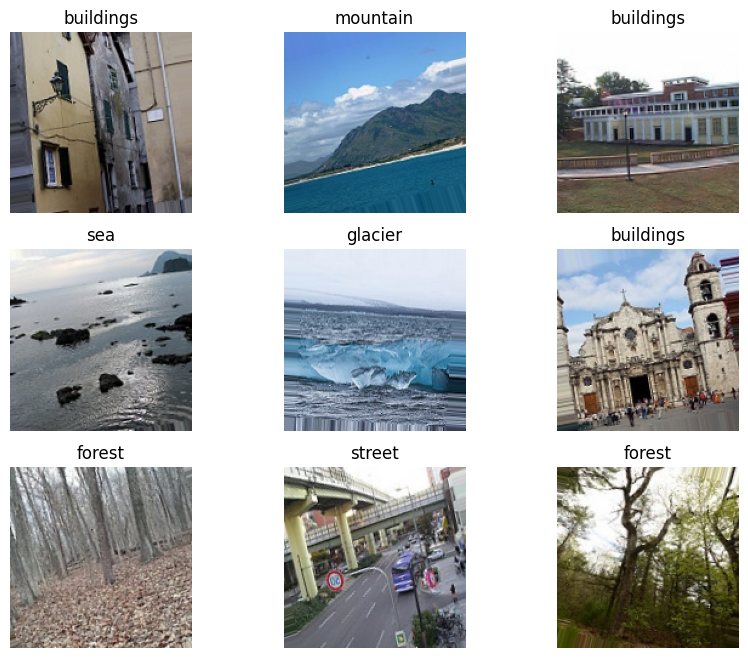

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = list(train_data.class_indices.keys())

images, labels = next(train_data)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

baseline_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(6, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,604,998 (36.64 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

Design, Train, Evaluate Baseline CNN (Model Training)

In [ ]:
BATCH_SIZE = 64

In [ ]:
baseline_history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 86s 202ms/step - accuracy: 0.5807 - loss: 1.0689 - val_accuracy: 0.6655 - val_loss: 0.8760
Epoch 2/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 190ms/step - accuracy: 0.7061 - loss: 0.7957 - val_accuracy: 0.7240 - val_loss: 0.7515
Epoch 3/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 189ms/step - accuracy: 0.7536 - loss: 0.6637 - val_accuracy: 0.7468 - val_loss: 0.6778
Epoch 4/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 190ms/step - accuracy: 0.7747 - loss: 0.6066 - val_accuracy: 0.7910 - val_loss: 0.6319
Epoch 5/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 189ms/step - accuracy: 0.8030 - loss: 0.5485 - val_accuracy: 0.8260 - val_loss: 0.4934


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
start_time = time.time()

baseline_history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

baseline_training_time = time.time() - start_time
print("Baseline training time:", baseline_training_time, "seconds")

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 189ms/step - accuracy: 0.8193 - loss: 0.5050 - val_accuracy: 0.7668 - val_loss: 0.6553
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 74s 189ms/step - accuracy: 0.8261 - loss: 0.4844 - val_accuracy: 0.8245 - val_loss: 0.5058
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 189ms/step - accuracy: 0.8357 - loss: 0.4550 - val_accuracy: 0.8081 - val_loss: 0.5724
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 74s 188ms/step - accuracy: 0.8472 - loss: 0.4267 - val_accuracy: 0.8367 - val_loss: 0.4665
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 74s 187ms/step - accuracy: 0.8569 - loss: 0.4020 - val_accuracy: 0.8331 - val_loss: 0.5043
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 189ms/step - accuracy: 0.8553 - loss: 0.3983 - val_accuracy: 0.8424 - val_loss: 0.4515
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 190ms/step - accuracy: 0.8615 - loss: 0.3795 - val_accuracy: 0.8545 - val_loss: 0.4787
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 74s 188ms/step - accuracy: 0.8662 - loss: 0

Model Evaluation

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step
              precision    recall  f1-score   support

   buildings       0.79      0.91      0.85       437
      forest       0.97      0.97      0.97       474
     glacier       0.81      0.84      0.83       553
    mountain       0.83      0.76      0.79       525
         sea       0.87      0.85      0.86       510
      street       0.90      0.85      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



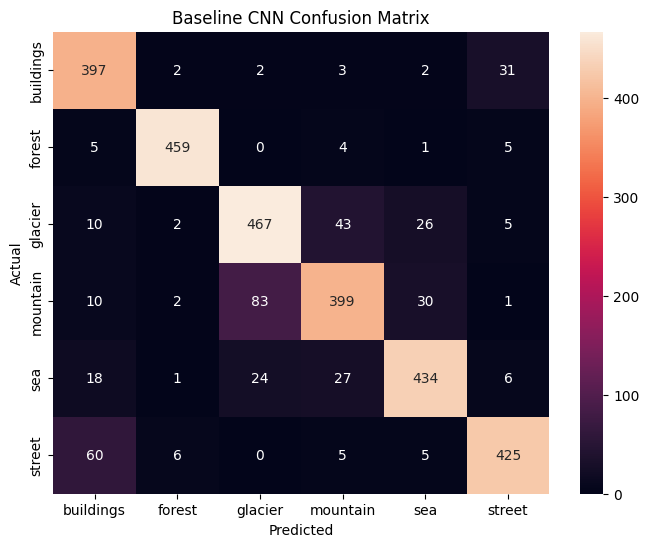

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

test_data.reset()

predictions = baseline_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CNN Confusion Matrix")
plt.show()

Deeper CNN with Regularization

In [ ]:
deeper_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.4),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 71, 71, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,695,654 (29.36 MB)

 Trainable params: 7,694,694 (29.35 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
deeper_history = deeper_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 114s 244ms/step - accuracy: 0.6231 - loss: 1.0013 - val_accuracy: 0.3581 - val_loss: 2.9414
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.7315 - loss: 0.7377 - val_accuracy: 0.6633 - val_loss: 1.0564
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.7608 - loss: 0.6492 - val_accuracy: 0.7325 - val_loss: 0.7758
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 81s 206ms/step - accuracy: 0.7883 - loss: 0.5850 - val_accuracy: 0.7718 - val_loss: 0.6177
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 83s 210ms/step - accuracy: 0.8018 - loss: 0.5476 - val_accuracy: 0.8153 - val_loss: 0.5301
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 81s 204ms/step - accuracy: 0.8100 - loss: 0.5235 - val_accuracy: 0.7033 - val_loss: 0.8080
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.8154 - loss: 0.5209 - val_accuracy: 0.7653 - val_loss: 0.7066
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 89s 224ms/step - accuracy: 0.8224 - loss: 

accuracy/loss graphs

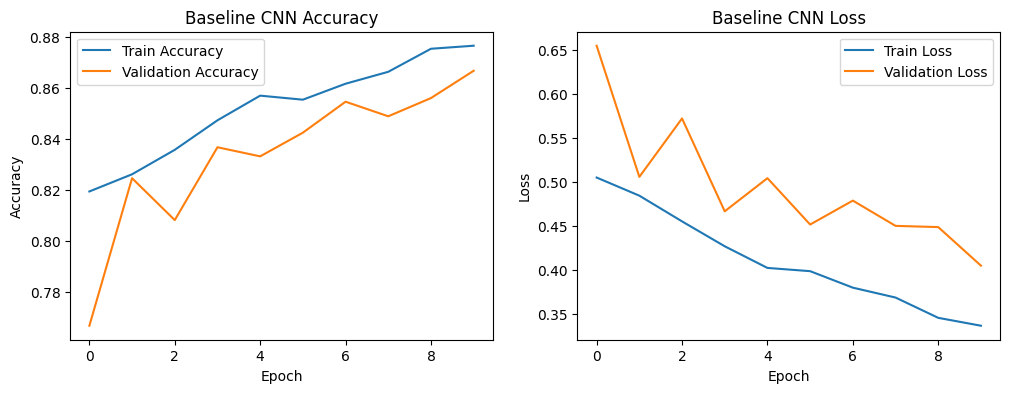

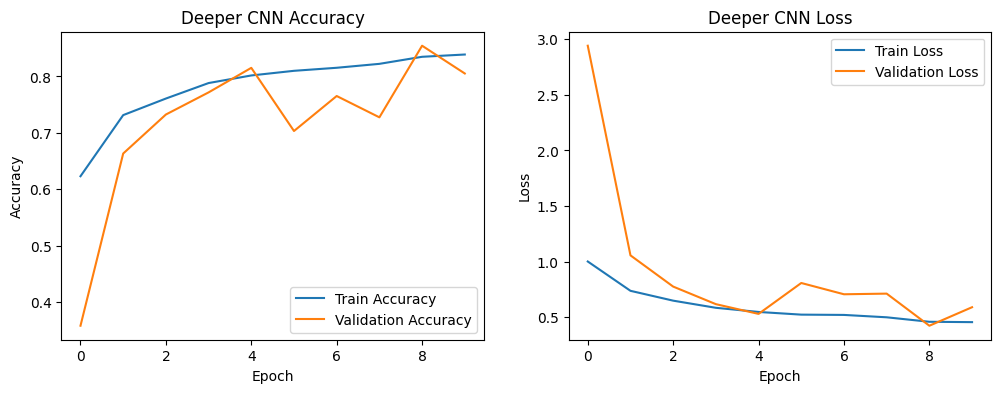

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(baseline_history, "Baseline CNN")
plot_history(deeper_history, "Deeper CNN")

SGD vs Adam

In [ ]:
from tensorflow.keras.optimizers import SGD

deeper_model_sgd = tf.keras.models.clone_model(deeper_model)

deeper_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deeper_model_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 96s 224ms/step - accuracy: 0.5547 - loss: 1.1623 - val_accuracy: 0.6098 - val_loss: 0.9794
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 206ms/step - accuracy: 0.6580 - loss: 0.8884 - val_accuracy: 0.6013 - val_loss: 1.0379
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 206ms/step - accuracy: 0.6982 - loss: 0.7996 - val_accuracy: 0.6633 - val_loss: 0.8548
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 81s 206ms/step - accuracy: 0.7246 - loss: 0.7386 - val_accuracy: 0.6990 - val_loss: 0.8079
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 211ms/step - accuracy: 0.7474 - loss: 0.6829 - val_accuracy: 0.7097 - val_loss: 0.8241
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.7587 - loss: 0.6610 - val_accuracy: 0.7953 - val_loss: 0.5633
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 83s 210ms/step - accuracy: 0.7810 - loss: 0.6121 - val_accuracy: 0.7304 - val_loss: 0.7516
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 212ms/step - accuracy: 0.7886 - loss: 0

Ablation Study

In [ ]:
ablation_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 93s 220ms/step - accuracy: 0.6733 - loss: 0.8741 - val_accuracy: 0.3959 - val_loss: 1.8330
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 83s 211ms/step - accuracy: 0.7563 - loss: 0.6596 - val_accuracy: 0.7917 - val_loss: 0.5864
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 81s 205ms/step - accuracy: 0.7931 - loss: 0.5641 - val_accuracy: 0.6705 - val_loss: 0.8972
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 208ms/step - accuracy: 0.8178 - loss: 0.5112 - val_accuracy: 0.7832 - val_loss: 0.6253
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 82s 208ms/step - accuracy: 0.8267 - loss: 0.4768 - val_accuracy: 0.7739 - val_loss: 0.6617
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 212ms/step - accuracy: 0.8402 - loss: 0.4384 - val_accuracy: 0.8203 - val_loss: 0.5075
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.8517 - loss: 0.4150 - val_accuracy: 0.8153 - val_loss: 0.5781
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 83s 210ms/step - accuracy: 0.8576 - loss: 0

Fine-Tuning Pretrained Model

Transfer Learning - MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze base

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(6, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

/tmp/ipykernel_9420/3992323720.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_history = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 119s 256ms/step - accuracy: 0.8162 - loss: 0.5146 - val_accuracy: 0.8830 - val_loss: 0.3265
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.8567 - loss: 0.3911 - val_accuracy: 0.8987 - val_loss: 0.2950
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.8699 - loss: 0.3654 - val_accuracy: 0.8980 - val_loss: 0.2845
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 74s 188ms/step - accuracy: 0.8714 - loss: 0.3511 - val_accuracy: 0.9009 - val_loss: 0.2689
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.8763 - loss: 0.3378 - val_accuracy: 0.8987 - val_loss: 0.2805
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 73s 185ms/step - accuracy: 0.8773 - loss: 0.3296 - val_accuracy: 0.8951 - val_loss: 0.2781
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 74s 187ms/step - accuracy: 0.8816 - loss: 0.3235 - val_accuracy: 0.9066 - val_loss: 0.2714
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 76s 193ms/step - accuracy: 0.8838 - loss: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, test_data, model_name):
    test_data.reset()

    predictions = model.predict(test_data)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    print(f"\n===== {model_name} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    acc = accuracy_score(y_true, y_pred)
    return acc

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

===== Baseline CNN Classification Report =====
              precision    recall  f1-score   support

   buildings       0.79      0.91      0.85       437
      forest       0.97      0.97      0.97       474
     glacier       0.81      0.84      0.83       553
    mountain       0.83      0.76      0.79       525
         sea       0.87      0.85      0.86       510
      street       0.90      0.85      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



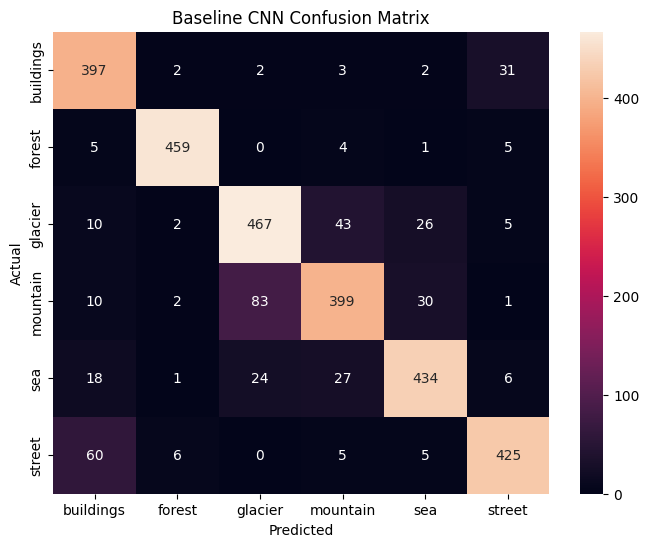

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step

===== Deeper CNN Classification Report =====
              precision    recall  f1-score   support

   buildings       0.78      0.87      0.82       437
      forest       0.73      0.99      0.84       474
     glacier       0.77      0.78      0.77       553
    mountain       0.81      0.74      0.78       525
         sea       0.88      0.80      0.84       510
      street       0.90      0.65      0.75       501

    accuracy                           0.80      3000
   macro avg       0.81      0.81      0.80      3000
weighted avg       0.81      0.80      0.80      3000



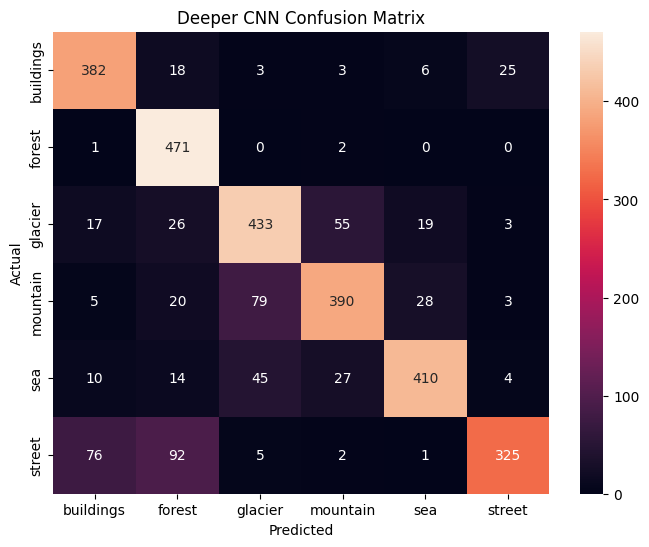

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step

===== Transfer Learning MobileNetV2 Classification Report =====
              precision    recall  f1-score   support

   buildings       0.91      0.90      0.90       437
      forest       0.98      1.00      0.99       474
     glacier       0.85      0.85      0.85       553
    mountain       0.84      0.84      0.84       525
         sea       0.95      0.91      0.93       510
      street       0.91      0.93      0.92       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



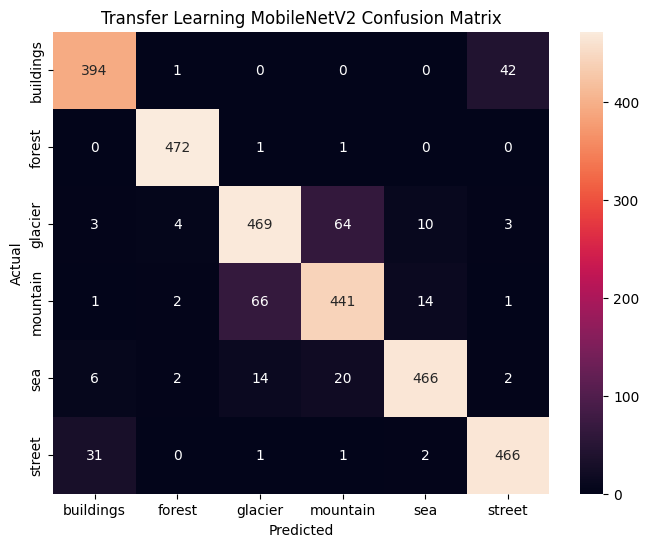

Baseline Test Accuracy: 0.8603333333333333
Deeper CNN Test Accuracy: 0.8036666666666666
Transfer Learning Test Accuracy: 0.9026666666666666


In [ ]:
baseline_test_acc = evaluate_model(baseline_model, test_data, "Baseline CNN")
deeper_test_acc = evaluate_model(deeper_model, test_data, "Deeper CNN")
transfer_test_acc = evaluate_model(transfer_model, test_data, "Transfer Learning MobileNetV2")

print("Baseline Test Accuracy:", baseline_test_acc)
print("Deeper CNN Test Accuracy:", deeper_test_acc)
print("Transfer Learning Test Accuracy:", transfer_test_acc)

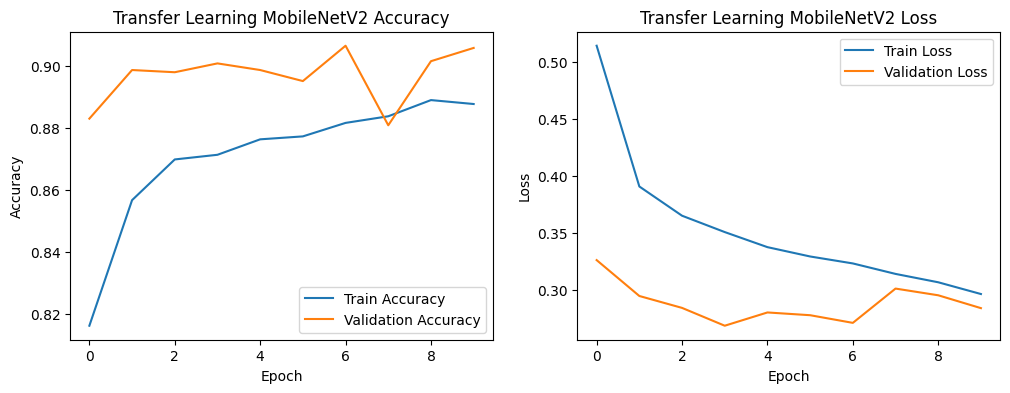

In [ ]:
plot_history(transfer_history, "Transfer Learning MobileNetV2")

In [1]:
import pandas as pd
import numpy as np

comparison_table = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deeper CNN with Dropout + BatchNorm",
        "Deeper CNN with SGD",
        "Ablation Model without Dropout",
        "Transfer Learning MobileNetV2"
    ],
    "Validation Accuracy": [
        "86.66%",
        "80.53%",
        "64.19% final (79.53% best)",
        "58.99% final (83.52% best)",
        "90.58%"
    ],
    "Test Accuracy": [
        "86.03%",
        "80.37%",
        "Not tested",
        "Not tested",
        "90.27%"
    ]
})

comparison_table

,Model,Validation Accuracy,Test Accuracy
0,Baseline CNN,86.66%,86.03%
1,Deeper CNN with Dropout + BatchNorm,80.53%,80.37%
2,Deeper CNN with SGD,64.19% final (79.53% best),Not tested
3,Ablation Model without Dropout,58.99% final (83.52% best),Not tested
4,Transfer Learning MobileNetV2,90.58%,90.27%


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


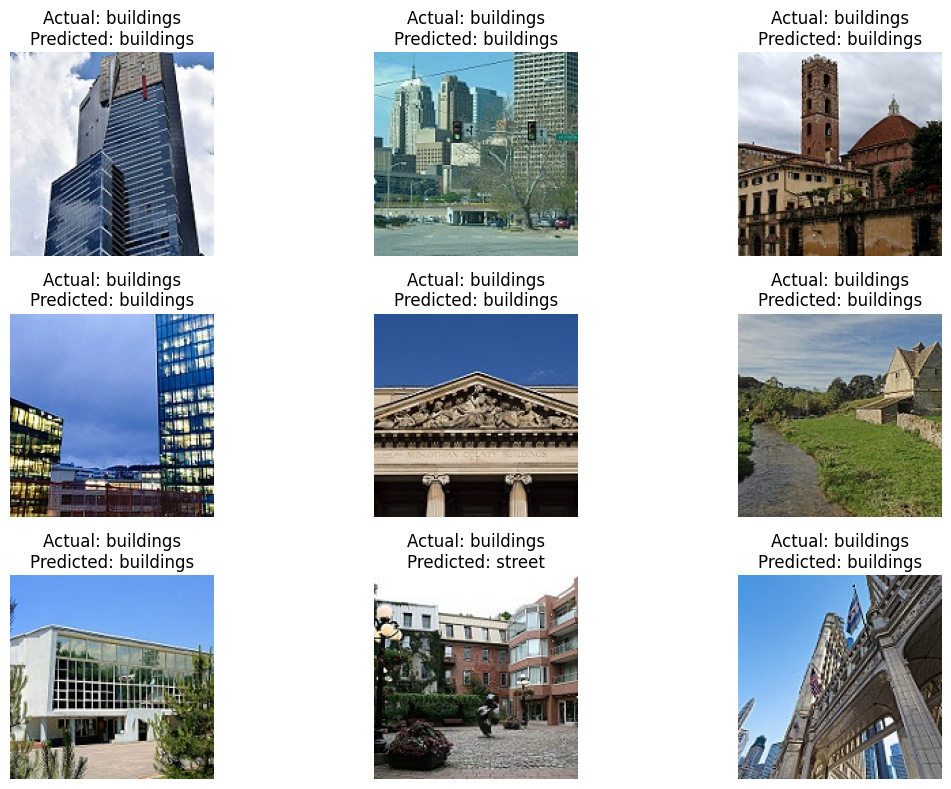

In [ ]:
test_data.reset()

images, labels = next(test_data)
predictions = transfer_model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])

    actual_label = class_names[np.argmax(labels[i])]
    predicted_label = class_names[np.argmax(predictions[i])]

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()